# EP1 — Ajuste controlado de hiperparámetros

Este notebook documenta el trabajo de Lucas Moncada en E3–E5. El objetivo es seleccionar una configuración candidata mediante comparaciones controladas de learning rate, batch size y capacidad. Todas las decisiones usan exclusivamente train y validation; el test oficial permanece sellado para evitar fuga de información.

## Protocolo experimental

Se parte del control aceptado por Ignacio: MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD, learning rate 0,01, batch 128, 20 épocas y sin regularización. La búsqueda es secuencial: cada familia modifica una sola variable, hereda la selección anterior y conserva seed 42 y el mismo split estratificado 54.000/6.000.

La selección no depende únicamente de accuracy: también considera F1 Macro, convergencia, gaps train-validation, duración y cantidad de parámetros. Las configuraciones son hipótesis verificables, no una receta inmutable.

In [1]:
from contextlib import redirect_stdout
from pathlib import Path
import io
import json
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))

from ep1_fashion_mnist.experiment import (
    plot_validation_comparison,
    run_validation_experiment,
)

print("Python executable:", sys.executable)
print("Project root:", ROOT)
assert ROOT.joinpath("uv.lock").exists(), "El notebook debe ejecutarse desde el repositorio"

Python executable: C:\Users\lucas\Documents\Deep-Learning-ev1\.venv\Scripts\python.exe
Project root: C:\Users\lucas\Documents\Deep-Learning-ev1


In [2]:
def execute_family(experiment_ids, family_name):
    rows = []
    histories = {}
    for experiment_id in experiment_ids:
        config_path = ROOT / "configs" / f"{experiment_id}.json"
        output_directory = ROOT / "results" / "runs" / experiment_id
        with redirect_stdout(io.StringIO()):
            run_validation_experiment(config_path, output_directory=output_directory)
        record_path = output_directory / f"{experiment_id}_validation_metrics.json"
        record = json.loads(record_path.read_text(encoding="utf-8"))
        config = record["config"]
        training = record["training"]
        metrics = record["metrics"]
        rows.append({
            "ID": experiment_id,
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "capacidad": str(config["hidden_layers"]),
            "parámetros": record["model_parameters"],
            "Accuracy": metrics["accuracy"],
            "Precision Macro": metrics["precision_macro"],
            "Recall Macro": metrics["recall_macro"],
            "F1 Macro": metrics["f1_macro"],
            "Precision ponderada": metrics["precision_weighted"],
            "Recall ponderado": metrics["recall_weighted"],
            "F1 ponderado": metrics["f1_weighted"],
            "mejor época accuracy": training["best_epoch_by_validation_accuracy"],
            "mejor época loss": training["best_epoch_by_validation_loss"],
            "gap accuracy": training["final_accuracy_gap"],
            "gap loss": training["final_loss_gap"],
            "duración (s)": training["duration_seconds"],
        })
        histories[experiment_id] = output_directory / f"{experiment_id}_history.csv"
        print(f"Completado: {experiment_id}")

    figures = ROOT / "results" / "figures"
    accuracy_path = figures / f"{family_name}_validation_accuracy.png"
    loss_path = figures / f"{family_name}_validation_loss.png"
    plot_validation_comparison(histories, metric="accuracy", output_path=accuracy_path)
    plot_validation_comparison(histories, metric="loss", output_path=loss_path)
    return pd.DataFrame(rows), accuracy_path, loss_path

METRIC_FORMATS = {
    "Accuracy": "{:.4f}",
    "Precision Macro": "{:.4f}",
    "Recall Macro": "{:.4f}",
    "F1 Macro": "{:.4f}",
    "Precision ponderada": "{:.4f}",
    "Recall ponderado": "{:.4f}",
    "F1 ponderado": "{:.4f}",
    "gap accuracy": "{:.4f}",
    "gap loss": "{:.4f}",
    "duración (s)": "{:.2f}",
}

## E3 — Learning rate

Se comparan 0,001, 0,01 y 0,1. Batch, arquitectura, funciones, optimizador y presupuesto permanecen fijos. La hipótesis es que 0,001 puede converger demasiado lento y 0,1 puede acelerar el aprendizaje, aunque debe vigilarse su estabilidad.

Completado: E3_lr_0_001


Completado: E3_lr_0_01


Completado: E3_lr_0_1


,ID,learning_rate,batch_size,capacidad,parámetros,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision ponderada,Recall ponderado,F1 ponderado,mejor época accuracy,mejor época loss,gap accuracy,gap loss,duración (s)
0,E3_lr_0_001,0.001000,128,"[256, 128]",235146,0.8053,0.8042,0.8053,0.8034,0.8042,0.8053,0.8034,20,20,-0.0065,-0.0113,22.41
1,E3_lr_0_01,0.010000,128,"[256, 128]",235146,0.8722,0.8737,0.8722,0.8726,0.8737,0.8722,0.8726,20,20,-0.0035,-0.0084,23.91
2,E3_lr_0_1,0.100000,128,"[256, 128]",235146,0.8933,0.8949,0.8933,0.8936,0.8949,0.8933,0.8936,13,18,0.0298,0.0885,22.50


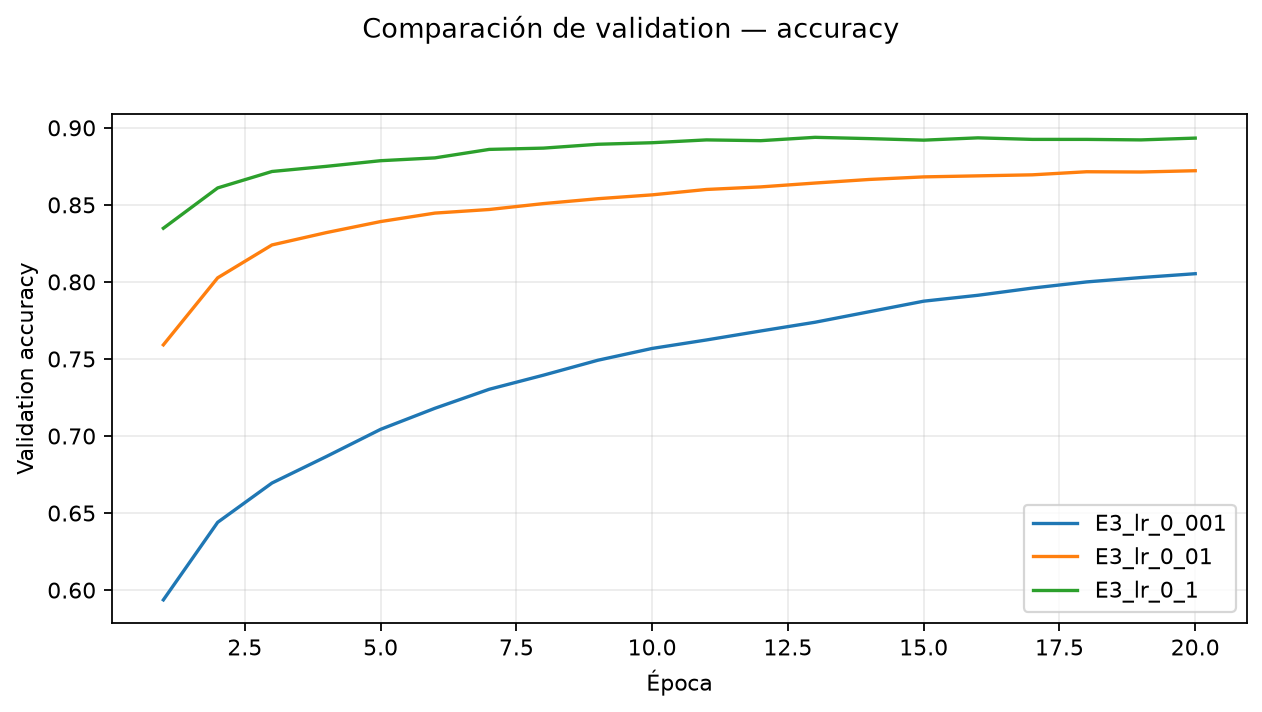

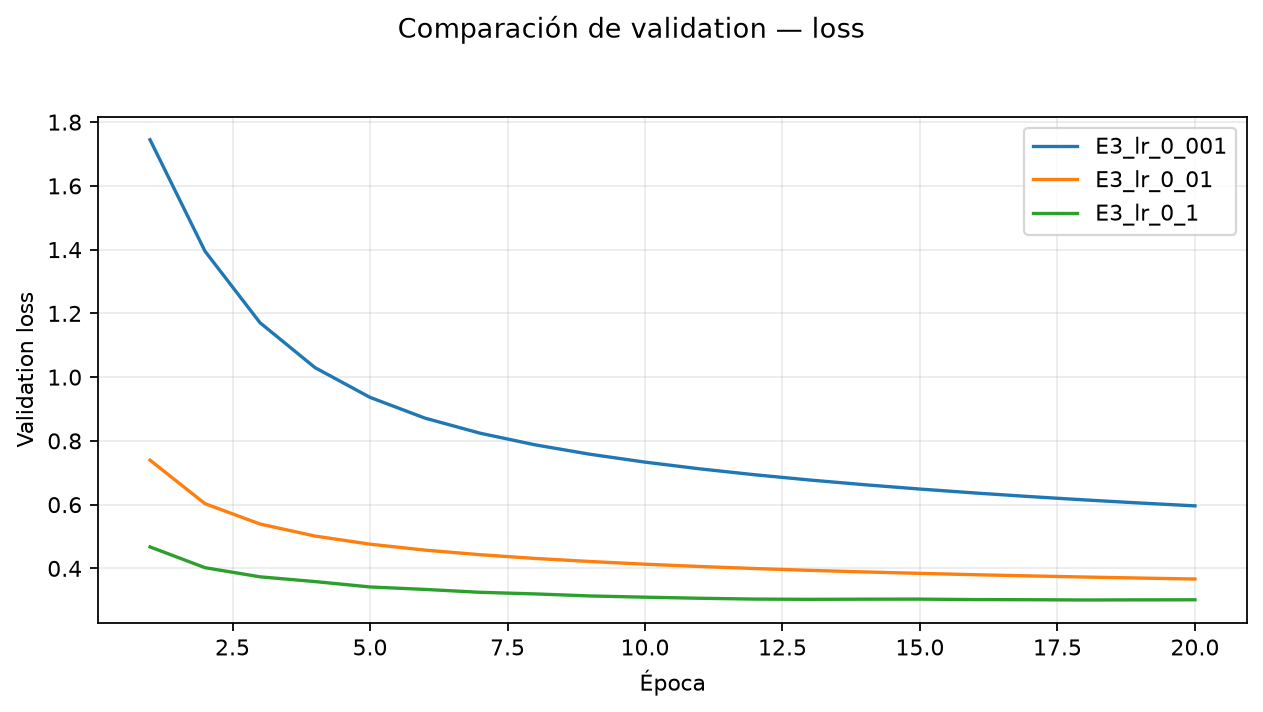

In [3]:
e3, e3_accuracy, e3_loss = execute_family(
    ["E3_lr_0_001", "E3_lr_0_01", "E3_lr_0_1"], "E3_learning_rate"
)
display(e3.style.format(METRIC_FORMATS))
display(Image(filename=str(e3_accuracy)))
display(Image(filename=str(e3_loss)))

### Decisión E3

Se selecciona `learning_rate=0.1`: obtuvo accuracy 0,8933 y F1 Macro 0,8936, aproximadamente 2,1 puntos por encima de 0,01 con costo temporal comparable. El valor 0,001 quedó subentrenado bajo el presupuesto común de 20 épocas. El mayor gap de 0,1 se conserva como riesgo para las etapas siguientes.

## E4 — Batch size

Con learning rate 0,1 seleccionado, se comparan batch 32, 128 y 512. El objetivo es medir el compromiso entre desempeño, generalización y costo por época sin cambiar otra variable.

Completado: E4_batch_32


Completado: E4_batch_128


Completado: E4_batch_512


,ID,learning_rate,batch_size,capacidad,parámetros,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision ponderada,Recall ponderado,F1 ponderado,mejor época accuracy,mejor época loss,gap accuracy,gap loss,duración (s)
0,E4_batch_32,0.100000,32,"[256, 128]",235146,0.8860,0.8883,0.8860,0.8864,0.8883,0.8860,0.8864,12,9,0.0534,0.2022,60.55
1,E4_batch_128,0.100000,128,"[256, 128]",235146,0.8933,0.8949,0.8933,0.8936,0.8949,0.8933,0.8936,13,18,0.0298,0.0885,22.34
2,E4_batch_512,0.100000,512,"[256, 128]",235146,0.8745,0.8871,0.8745,0.8771,0.8871,0.8745,0.8771,19,20,0.0100,0.0303,10.52


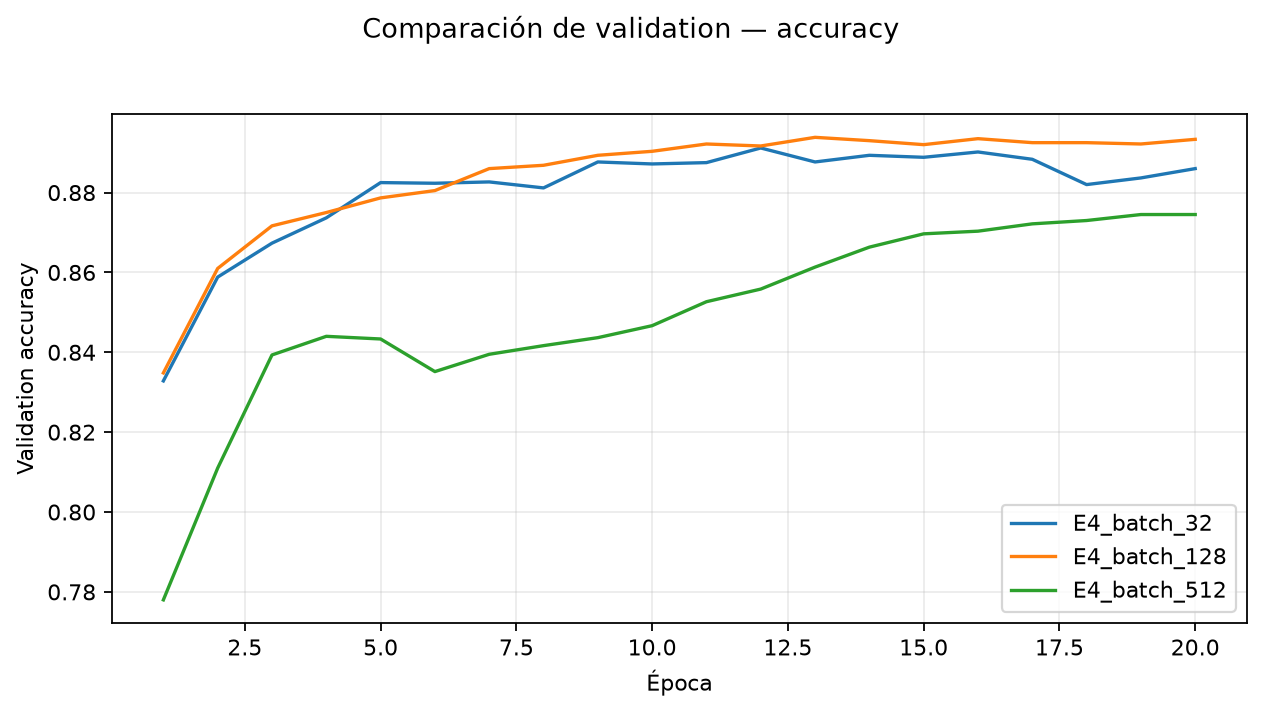

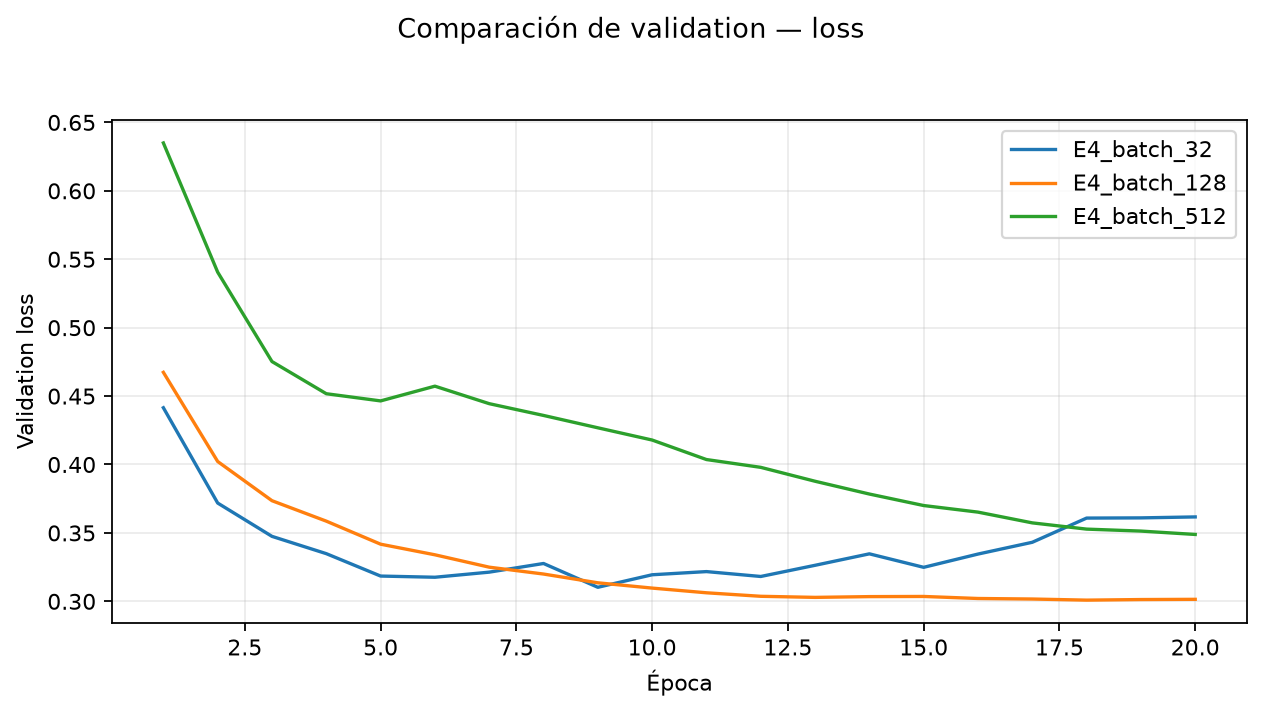

In [4]:
e4, e4_accuracy, e4_loss = execute_family(
    ["E4_batch_32", "E4_batch_128", "E4_batch_512"], "E4_batch_size"
)
display(e4.style.format(METRIC_FORMATS))
display(Image(filename=str(e4_accuracy)))
display(Image(filename=str(e4_loss)))

### Decisión E4

Se mantiene `batch_size=128`. Batch 32 fue más lento, terminó con menor desempeño y mostró deterioro de validation después de sus mejores épocas. Batch 512 redujo el tiempo y los gaps, pero perdió 1,88 puntos de accuracy. El valor 128 conserva la mayor accuracy y F1 Macro con costo intermedio.

## E5 — Capacidad de la MLP

Con learning rate 0,1 y batch 128 se comparan `[64]`, `[256, 128]` y `[512, 256, 128]`. Una red mayor solo debe seleccionarse si la mejora compensa parámetros, tiempo y riesgo de sobreajuste.

Completado: E5_capacity_64


Completado: E5_capacity_256_128


Completado: E5_capacity_512_256_128


,ID,learning_rate,batch_size,capacidad,parámetros,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision ponderada,Recall ponderado,F1 ponderado,mejor época accuracy,mejor época loss,gap accuracy,gap loss,duración (s)
0,E5_capacity_64,0.100000,128,[64],50890,0.8873,0.8901,0.8873,0.8881,0.8901,0.8873,0.8881,20,20,0.0100,0.0256,14.68
1,E5_capacity_256_128,0.100000,128,"[256, 128]",235146,0.8933,0.8949,0.8933,0.8936,0.8949,0.8933,0.8936,13,18,0.0298,0.0885,23.17
2,E5_capacity_512_256_128,0.100000,128,"[512, 256, 128]",567434,0.8990,0.8996,0.8990,0.8989,0.8996,0.8990,0.8989,20,16,0.0379,0.1215,34.06


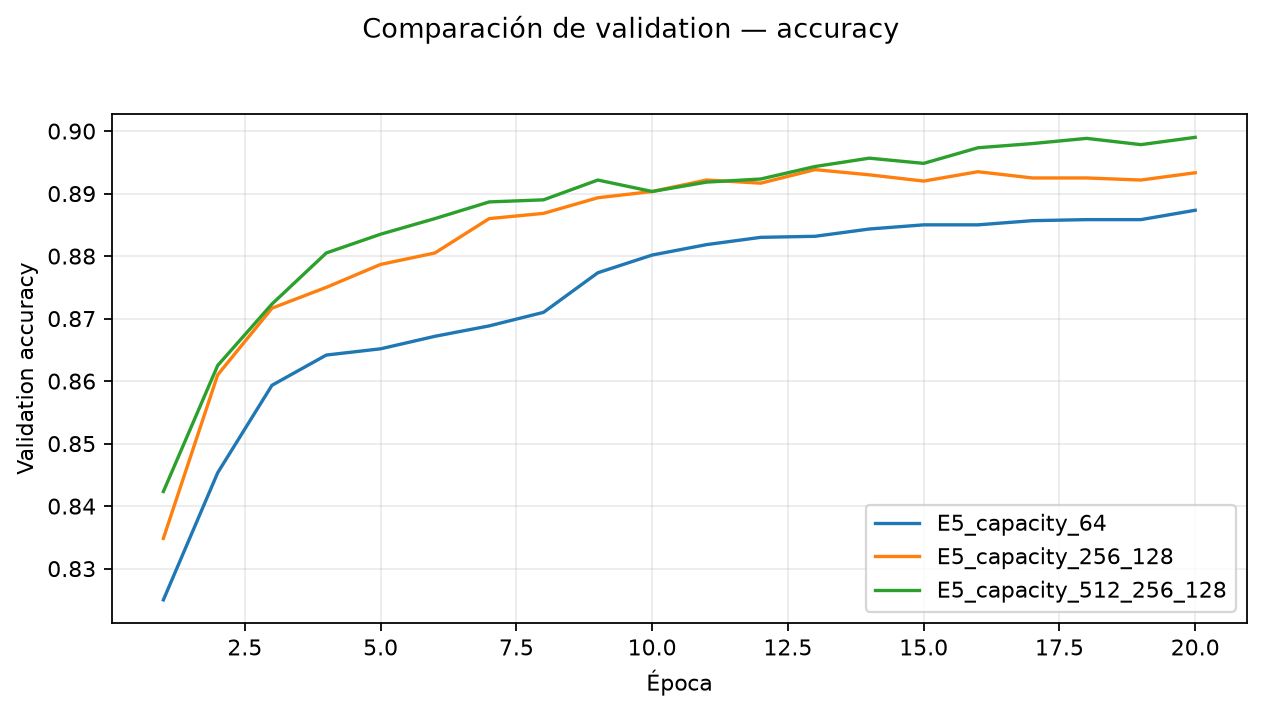

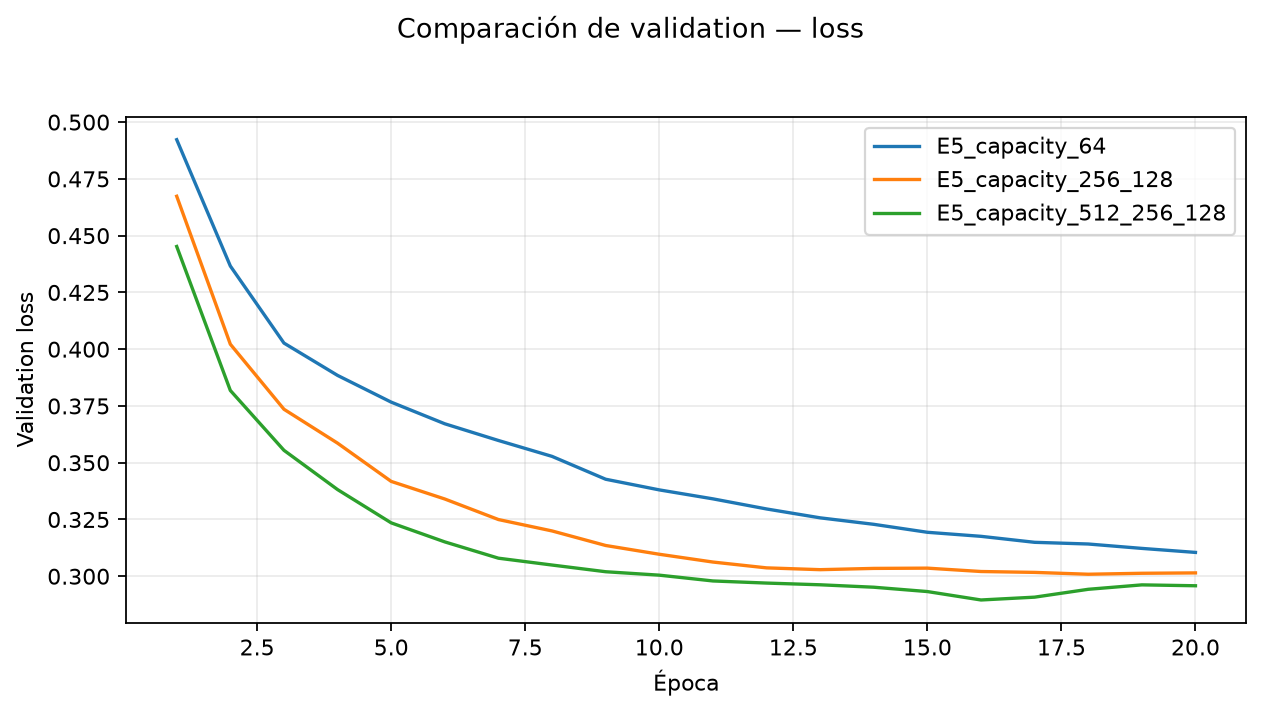

In [5]:
e5, e5_accuracy, e5_loss = execute_family(
    ["E5_capacity_64", "E5_capacity_256_128", "E5_capacity_512_256_128"],
    "E5_capacity",
)
display(e5.style.format(METRIC_FORMATS))
display(Image(filename=str(e5_accuracy)))
display(Image(filename=str(e5_loss)))

### Decisión E5

La candidata equilibrada es `[256, 128]`. La red grande alcanza accuracy 0,8990, pero mejora solo 0,57 puntos frente al control usando 2,41 veces más parámetros, más tiempo de entrenamiento y gaps mayores. La duración puede variar entre ejecuciones y solo se compara dentro del mismo entorno; no es el único criterio de selección. La red `[64]` es compacta, aunque pierde desempeño. La candidata conserva 235.146 parámetros, accuracy 0,8933 y F1 Macro 0,8936.

## Decisión condicional sobre Early Stopping

No se añade un experimento con callback en esta etapa. Para `[256, 128]`, la mejor `val_loss` fue 0,3009 en la época 18 y la final 0,3015; el deterioro aproximado de 0,0006 no es material y el ahorro potencial sería de dos épocas. La red grande sí muestra una separación mayor después de la época 16, pero no fue seleccionada. Cesar deberá reevaluar Early Stopping si sus cambios de optimizador o regularización alteran la convergencia.

In [6]:
candidate = e5.loc[e5["ID"] == "E5_capacity_256_128"].copy()
candidate.insert(1, "optimizador", "SGD")
candidate.insert(2, "activación", "ReLU")
candidate.insert(3, "loss", "categorical_crossentropy")
display(candidate.style.format(METRIC_FORMATS))
assert candidate.iloc[0]["learning_rate"] == 0.1
assert candidate.iloc[0]["batch_size"] == 128
assert candidate.iloc[0]["capacidad"] == "[256, 128]"
print("Candidata validada para el Handoff 03; test oficial no evaluado.")

,ID,optimizador,activación,loss,learning_rate,batch_size,capacidad,parámetros,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision ponderada,Recall ponderado,F1 ponderado,mejor época accuracy,mejor época loss,gap accuracy,gap loss,duración (s)
1,E5_capacity_256_128,SGD,ReLU,categorical_crossentropy,0.100000,128,"[256, 128]",235146,0.8933,0.8949,0.8933,0.8936,0.8949,0.8933,0.8936,13,18,0.0298,0.0885,23.17


Candidata validada para el Handoff 03; test oficial no evaluado.


## Handoff a Cesar

Cesar recibe como control una MLP `[256, 128]`, ReLU, Softmax, categorical crossentropy, SGD con learning rate 0,1, batch 128, 20 épocas, seed 42 y sin regularización. La configuración es candidata y puede cambiar con evidencia al comparar SGD, RMSProp y Adam y luego técnicas de regularización. El test debe permanecer sellado hasta congelar configuración y protocolo final.